In [1]:
%matplotlib widget
import numpy as np
import scipp as sc
import tof
from trex.instrument import Instrument
from trex.components.source import Source


central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=1)
res_elastic_rrm16 = trex.model.run()

In [2]:
# define an inelastic sample
rng = np.random.default_rng(seed=42)


def uniform_delta_e(e_i):
    # Uniform sampling between 40 and 50 meV
    de = sc.array(dims=e_i.dims, values=rng.uniform(40, 50, size=e_i.shape), unit="meV")
    return e_i.to(unit="meV", copy=False) - de


sample = tof.InelasticSample(
    distance=trex.monitors["Monitor at Sample"].distance,
    name="sample",
    func=uniform_delta_e,
)  # type: ignore
trex.sample = sample
res_inelastic_rrm16 = trex.model.run()

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_72217/71468831.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


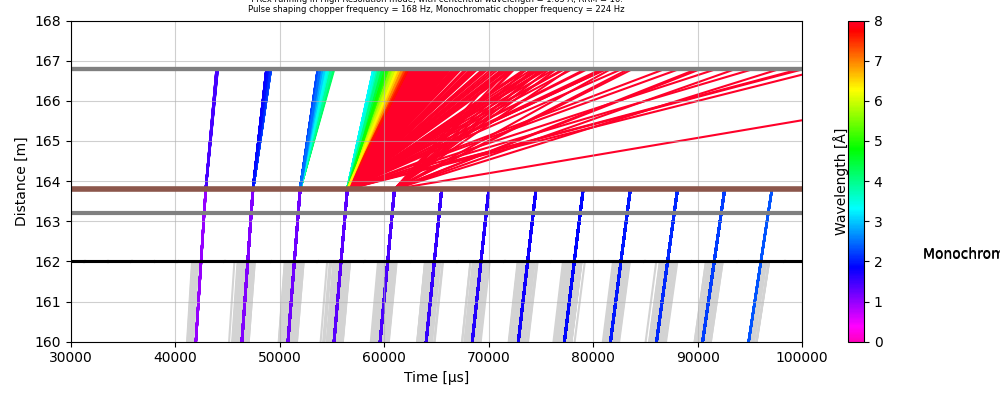

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm16.plot(
    visible_rays=20_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=8
)
ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

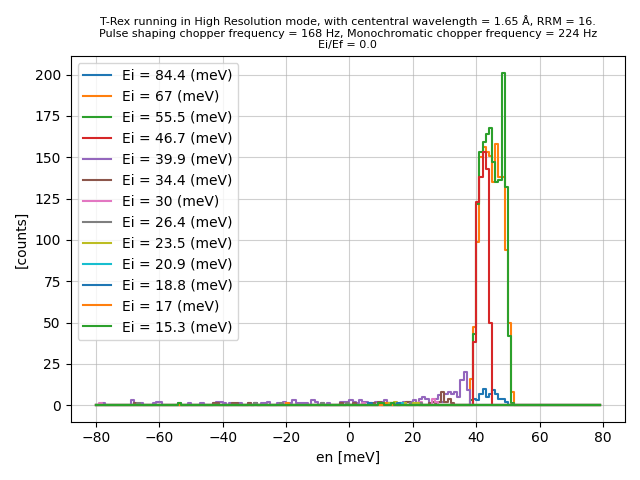

In [4]:
import plopp as pp

ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

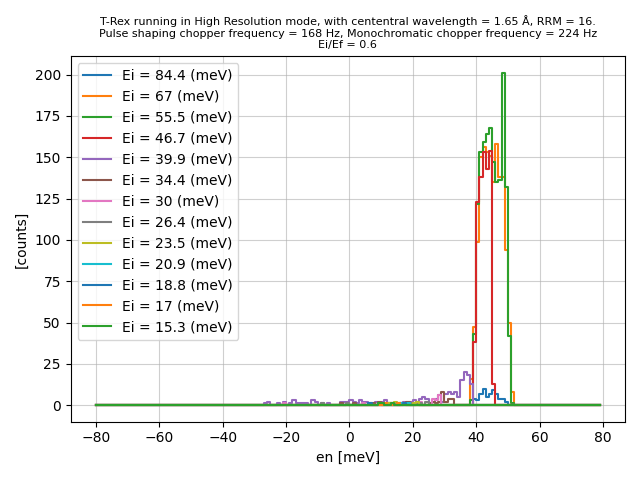

In [5]:
import plopp as pp

ei_ef_ratio = 0.6
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

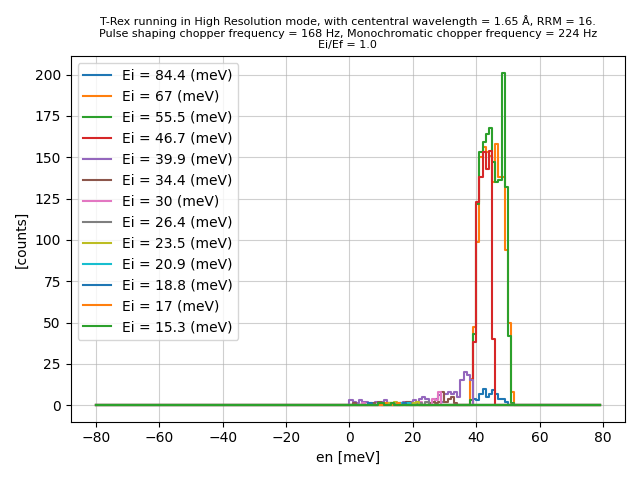

In [6]:
import plopp as pp

ei_ef_ratio = 1.0
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

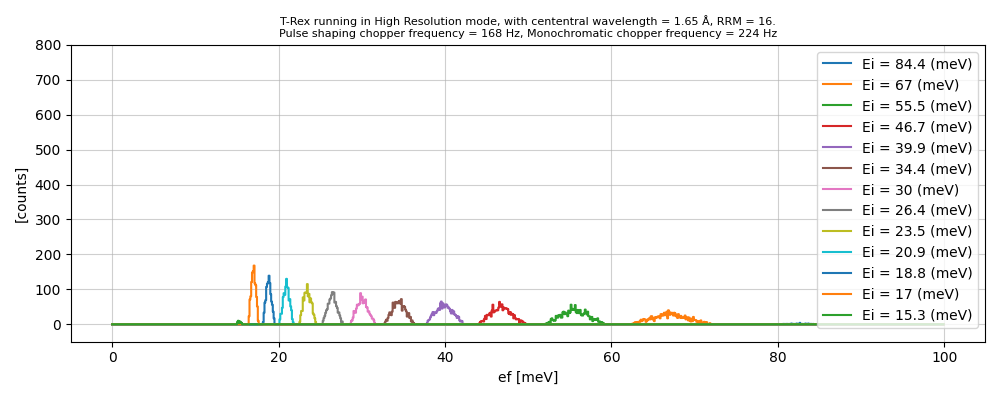

In [7]:
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm16, *params)

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 800])
fig.tight_layout()

In [ ]:
central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 8
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=1)
res_elastic_rrm8 = trex.model.run()
trex.sample = sample
res_inelastic_rrm8 = trex.model.run()

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_72217/3387464201.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


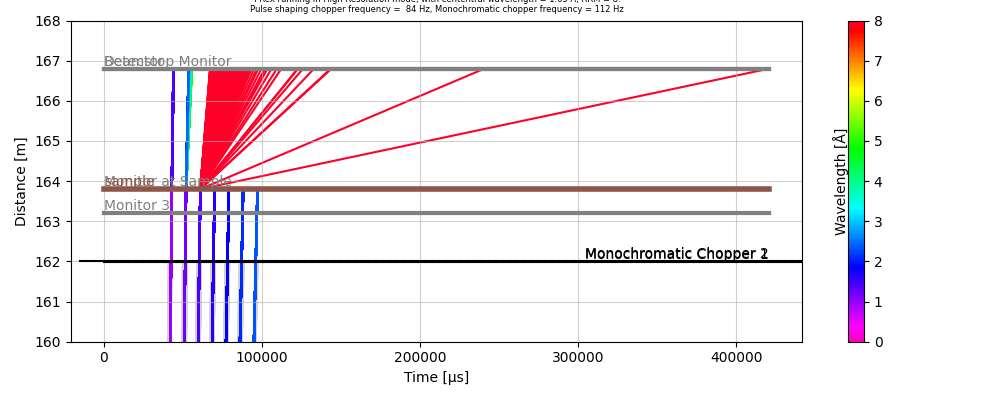

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm8.plot(
    visible_rays=2_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=8
)
# ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

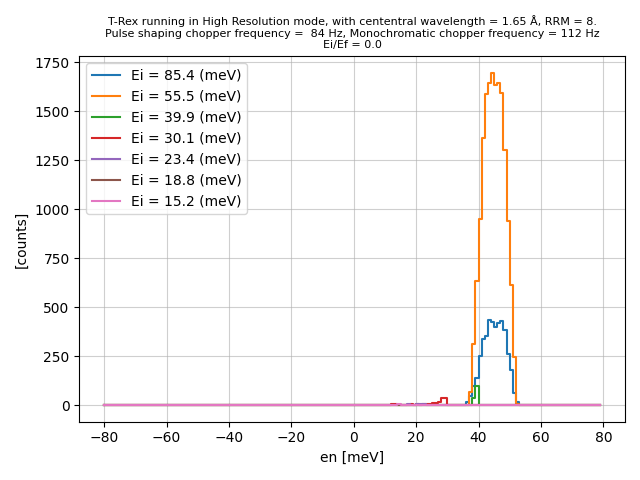

In [10]:
ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm8, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res_inelastic_rrm8, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

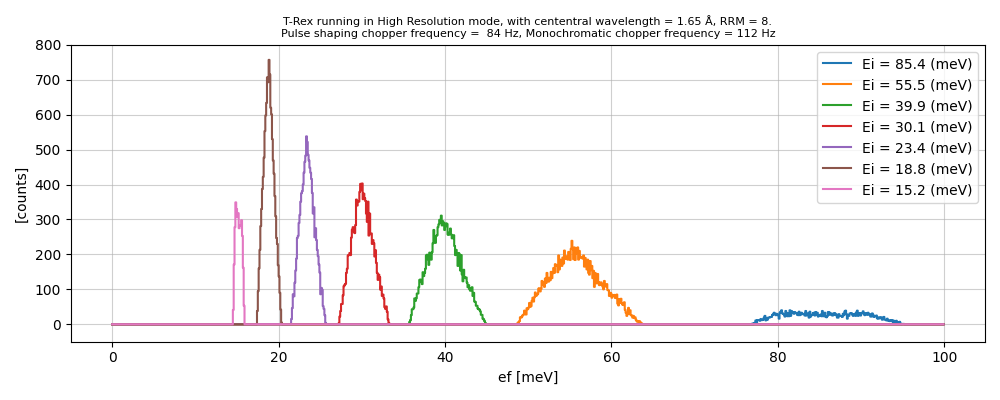

In [11]:
reduced_list = trex.toa_to_energy(res_elastic_rrm8, *params)

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 800])
fig.tight_layout()

In [17]:
central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 4
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=3)
res_elastic_rrm4 = trex.model.run()
trex.sample = sample
res_inelastic_rrm4 = trex.model.run()

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_72217/34098877.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


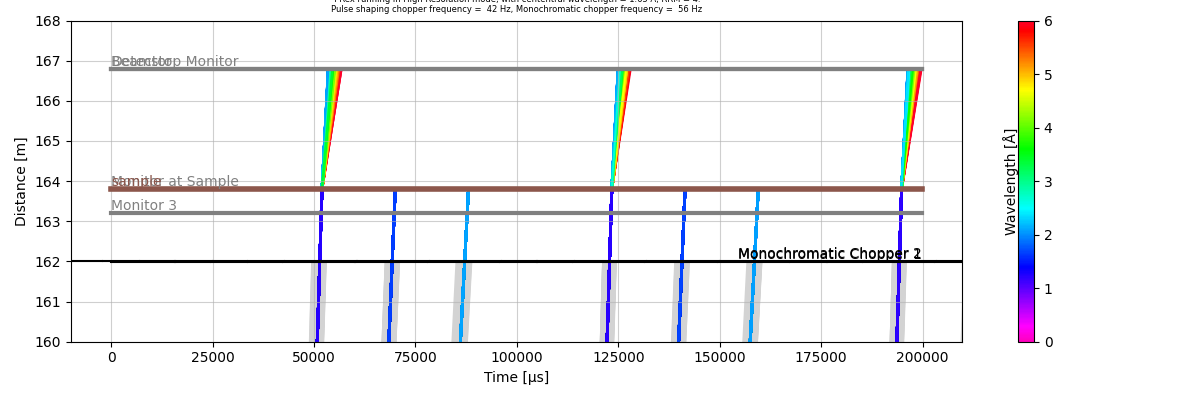

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm4.plot(
    visible_rays=20_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=6
)
# ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

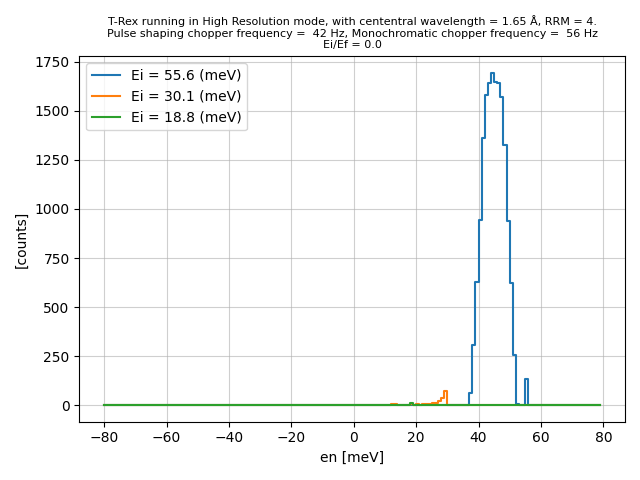

In [25]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm4)
params = trex.unwrap_frame(res_elastic_rrm4, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res_inelastic_rrm8, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_72217/2390256405.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 4))


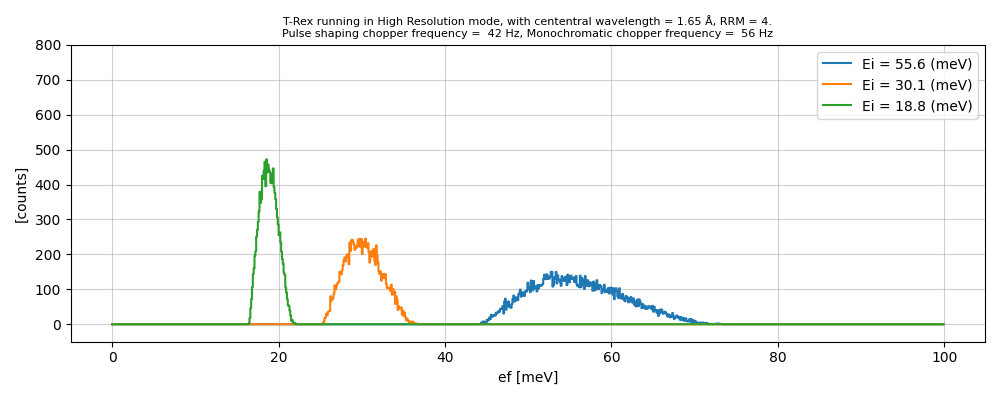

In [26]:
reduced_list = trex.toa_to_energy(res_elastic_rrm4, *params)

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 800])
fig.tight_layout()